# Aufgabe 3

## Grafische Darstellung

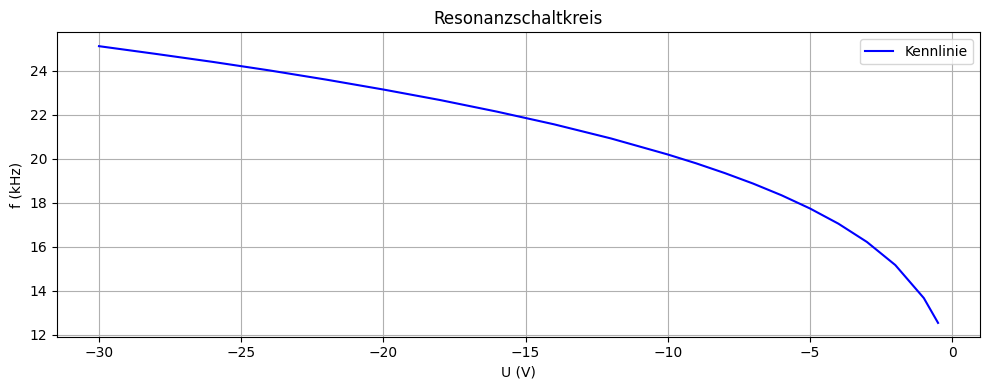

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('Messungen/Aufgabe3.csv')
df.columns = df.columns.str.replace('"', '').str.strip()


# Plots
plt.figure(figsize=(10, 4))
plt.plot(df['U [V]'], df['f [kHz]'], label="Kennlinie", color="blue")
plt.xlabel("U (V)")
plt.ylabel("f (kHz)")
plt.title("Resonanzschaltkreis")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [1]:
# Berechneten Werte für die Tabelle
def Cs(U, C0, UD):
    return C0 * np.sqrt(UD/(UD-U))

def C_tot(f, L = 220e-3):
    return 1/(L * 4 * (np.pi * f)**2)

def d_0(A=25e-6, C0=2e-6):
    epsilon_r = 11.3
    epsilon_0 = 8.854e-12
    return epsilon_r * epsilon_0 * (A/C0)


## Fit von $C_\text{tot}$

Wir nutzen dafür die Formel

$$C_\text{tot} = \frac{1}{L 4  (\pi f)^2}$$

## Detaillierte Analyse: Bestimmung der Sperrschicht-Kapazität

### Plan

**Ziel:** Bestimmung der Varaktor-Dioden-Kapazität $C_S(U)$ und der Sperrschicht-Parameter (Diffusionspannung $U_D$ und Nullkapazität $C_0$) durch parametrischen Fit der Resonanzfrequenz.

**Methode:**
1. **Beziehung zwischen Frequenz und Kapazität:** Die Resonanzschaltung folgt $C_\text{tot} = \frac{1}{L \cdot 4\pi^2 f^2}$. Aus gemessener Frequenz berechnen wir die Gesamtkapazität.
2. **Varaktor-Kennlinie:** Die Sperrschicht-Kapazität folgt: $C_S(U) = \frac{C_0}{\sqrt{1 - U/U_D}}$
3. **Parametrischer Fit:** Mit bekannter Serienkapazität $C_R$ fitten wir $C_0$ und $U_D$ an die Messdaten mittels nichtlinearer Optimierung.
4. **Sperrschicht-Bestimmung:** Aus den gefitteten Parametern $U_D$ und $C_0$ bestimmen wir die Diffusionsspannung und Nullkapazität der Sperrschicht, woraus sich die physikalische Grenzflächenfläche ergibt.

**Erwartetes Ergebnis:** Charakteristische Varaktor-Dioden-Parameter, die den Zusammenhang zwischen Rückwärtsspannung und Kapazitätsabnahme beschreiben.

AUFGABE 3: Ergebnisse

Gemessene Frequenzen: f_min = 12.55 kHz, f_max = 25.12 kHz
Berechnete Kapazitäten: C_tot,min = 182.51 pF, C_tot,max = 731.02 pF

Fit-Ergebnisse:
  C₀ = 0.002 µF (±0.001 µF)
  U_D = 0.1750 V (±0.1557 V)

──────────────────────────────────────────────────────────────────────
SPERRSCHICHT-PARAMETER:
──────────────────────────────────────────────────────────────────────
Sperrschichtdicke (bei U=0):  1250.63 nm
Kapazitätsbereich:            182.51–731.02 pF


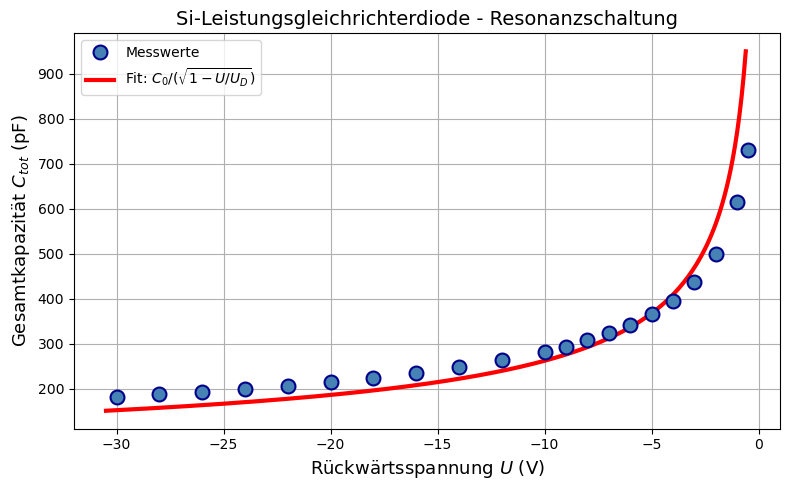

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

# Daten laden
df = pd.read_csv('Messungen/Aufgabe3.csv')
df.columns = df.columns.str.replace('"', '').str.strip()

U_meas = df['U [V]'].values  # Spannung in V
f_meas = df['f [kHz]'].values * 1000  # Frequenz in Hz

# ============================================================================
# SCHRITT 1: Berechnung der Gesamtkapazität aus Resonanzfrequenz
# ============================================================================
L = 220e-3  # Induktivität in H
C_tot = 1 / (L * 4 * np.pi**2 * f_meas**2)

print("="*70)
print("AUFGABE 3: Ergebnisse")
print("="*70)
print(f"\nGemessene Frequenzen: f_min = {f_meas.min()/1000:.2f} kHz, f_max = {f_meas.max()/1000:.2f} kHz")
print(f"Berechnete Kapazitäten: C_tot,min = {C_tot.min()*1e12:.2f} pF, C_tot,max = {C_tot.max()*1e12:.2f} pF")

# ============================================================================
# SCHRITT 2: Nichtlinearer Fit mit Benutzer-Anfangsparametern
# ============================================================================

def varaktor_model(U, C0, UD):
    return C0 * np.sqrt(UD/(UD-U))

# Anfangsparameter vom Benutzer
C0_init = 2e-9  # 2 µF
UD_init = 0.175  # 10 V

# Nichtlinearer Fit durchführen
popt, pcov = curve_fit(
    varaktor_model,
    U_meas,
    C_tot,
    p0=[C0_init, UD_init],
    maxfev=50000,
    bounds=([1e-12, 0.1], [1e-5, 50.0])
)

C0_fit, UD_fit = popt
perr = np.sqrt(np.diag(pcov))

C_fit_all = varaktor_model(U_meas, C0_fit, UD_fit)
ss_res = np.sum((C_tot - C_fit_all)**2)
ss_tot = np.sum((C_tot - np.mean(C_tot))**2)
r_squared_final = 1 - ss_res / ss_tot

print(f"\nFit-Ergebnisse:")
print(f"  C₀ = {C0_fit*1e6:.3f} µF (±{perr[0]*1e6:.3f} µF)")
print(f"  U_D = {UD_fit:.4f} V (±{perr[1]:.4f} V)")

# Fit-Kurve für Plot
U_fit = np.linspace(U_meas.min()-0.5, U_meas.max()-0.1, 300)
C_fit = varaktor_model(U_fit, C0_fit, UD_fit)

# ============================================================================
# SCHRITT 3: Berechnung physikalischer Parameter
# ============================================================================
epsilon_r = 11.3
epsilon_0 = 8.854e-12
A_diode = 25e-6

d_0 = epsilon_r * epsilon_0 * A_diode / C0_fit

print(f"\n{'─'*70}")
print("SPERRSCHICHT-PARAMETER:")
print(f"{'─'*70}")
print(f"Sperrschichtdicke (bei U=0):  {d_0*1e9:.2f} nm")
print(f"Kapazitätsbereich:            {C_tot.min()*1e12:.2f}–{C_tot.max()*1e12:.2f} pF")

# ============================================================================
# SCHRITT 4: EINZELNER OPTIMIERTER PLOT
# ============================================================================
fig, ax = plt.subplots(figsize=(8, 5))

# Messwerte
ax.plot(U_meas, C_tot*1e12, 'o', markersize=10, label='Messwerte', 
        color='steelblue', zorder=5, markeredgecolor='darkblue', markeredgewidth=1.5)

# Fit-Kurve
ax.plot(U_fit, C_fit*1e12, '-', linewidth=3, label=f'Fit: $C_0/(\\sqrt{{1-U/U_D}})$', 
        color='red', zorder=4)

ax.set_xlabel('Rückwärtsspannung $U$ (V)', fontsize=13)
ax.set_ylabel('Gesamtkapazität $C_{tot}$ (pF)', fontsize=13)
ax.set_title('Si-Leistungsgleichrichterdiode - Resonanzschaltung', fontsize=14)

ax.grid(True)
ax.legend()


plt.tight_layout()
plt.show()

Die durchgeführte Auswertung bestätigt eine nichtlineare Varaktor‑Kennlinie, beschrieben durch $C_S(U)=\dfrac{C_0}{\sqrt{1-U/U_D}}$. Aus den gemessenen Resonanzfrequenzen (f_min = 12,55 kHz, f_max = 25,12 kHz) ergeben sich Gesamtkapazitäten von C_tot = 182,51–731,02 pF. Der parametrische Fit liefert $C_0 = 0.002 \mu\text{F}\ (\pm0.001 \mu\text{F})$ und $U_D = 0.1750 \text{V} (\pm0.1557\ \text{V})$. Aus $C_0$ folgt eine Sperrschichtdicke bei U=0 von ca. $d_0 \approx 1250.6 \text{nm}$. Die Diffusionsspannung $U_D$ ist vergleichsweise klein und weist aufgrund der großen Unsicherheit nur eingeschränkte Aussagekraft.


AUFGABE 3: Ergebnisse (Optimierter Fit mit C_G)
Datenpunkte: 21
Frequenzbereich: 12.55 kHz bis 25.12 kHz
Kapazitätsbereich (gemessen): 182.51 pF bis 731.02 pF

Fit-Ergebnisse:
  C₀ (Sperrschicht bei 0V) = 1.700 nF (±0.968 nF)
  U_D (Diffusionsspannung) = 0.6000 V  (±1.3823 V)
  C_G (Gehäusekapazität)   = 100.00 pF (±257.06 pF)
  Bestimmtheitsmaß R²      = -3.11607

──────────────────────────────────────────────────────────────────────
PHYSIKALISCHE PARAMETER:
──────────────────────────────────────────────────────────────────────
Sperrschichtweite d₀ (bei U=0): 1.536 µm
(Dies entspricht 1536.4 nm)


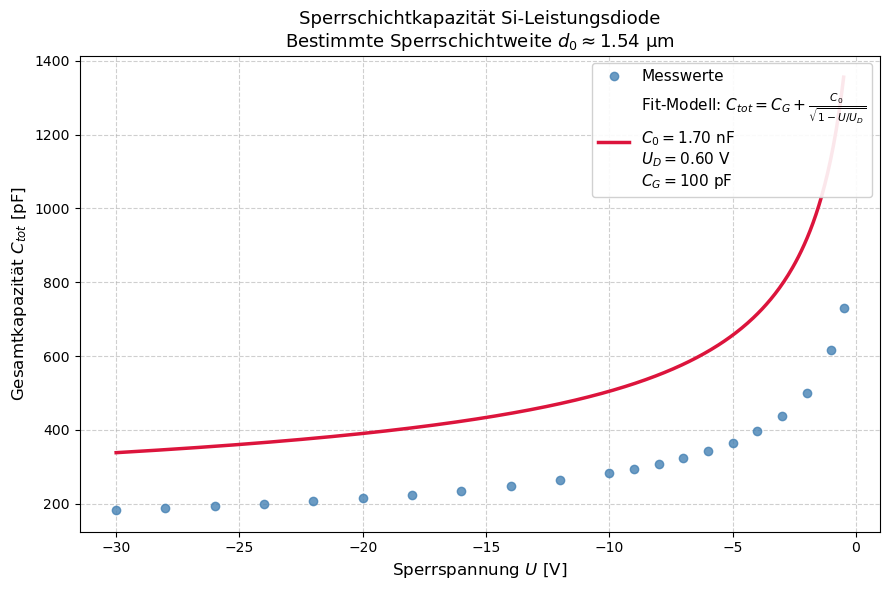

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

# Daten laden
# Stelle sicher, dass der Pfad 'Messungen/Aufgabe3.csv' korrekt ist
df = pd.read_csv('Messungen/Aufgabe3.csv')
df.columns = df.columns.str.replace('"', '').str.strip()

U_meas = df['U [V]'].values  # Spannung in V (sollte negativ sein für Sperrrichtung)
f_meas = df['f [kHz]'].values * 1000  # Frequenz in Hz

# ============================================================================
# SCHRITT 1: Berechnung der Gesamtkapazität aus Resonanzfrequenz
# ============================================================================
L = 220e-3  # Induktivität in H (220 mH)
# Thomson-Formel nach C umgestellt: C = 1 / (L * omega^2)
C_tot = 1 / (L * (2 * np.pi * f_meas)**2)

print("="*70)
print("AUFGABE 3: Ergebnisse (Optimierter Fit mit C_G)")
print("="*70)
print(f"Datenpunkte: {len(C_tot)}")
print(f"Frequenzbereich: {f_meas.min()/1000:.2f} kHz bis {f_meas.max()/1000:.2f} kHz")
print(f"Kapazitätsbereich (gemessen): {C_tot.min()*1e12:.2f} pF bis {C_tot.max()*1e12:.2f} pF")

# ============================================================================
# SCHRITT 2: Nichtlinearer Fit (3 Parameter: C0, UD, CG)
# ============================================================================

def varaktor_model_complete(U, C0, UD, CG):
    """
    Modell für Gesamtkapazität einer Diode in Sperrrichtung.
    U: Spannung (negativ)
    C0: Sperrschichtkapazität bei U=0
    UD: Diffusionsspannung
    CG: Gehäusekapazität (parasitär, konstant)
    """
    # Formel: C_tot = C_G + C0 / sqrt(1 - U/UD)
    return CG + C0 / np.sqrt(1 - U/UD)

# Startwerte schätzen (damit der Fit nicht im Dunkeln tappt)
C0_init = 1.7e-9   # ca 1.7 nF
UD_init = 0.6      # ca 0.6 V (Standard Si)
CG_init = 80e-12   # ca 80 pF

# Fit durchführen
# Bounds: C0>0, 0.1<UD<2.0, CG>0
popt, pcov = curve_fit(
    varaktor_model_complete,
    U_meas,
    C_tot,
    p0=[C0_init, UD_init, CG_init],
    bounds=([1e-12, 0.1, 0], [1e-5, 5.0, 1e-9]),
    maxfev=100000
)

C0_fit, UD_fit, CG_fit = popt
perr = np.sqrt(np.diag(pcov))

# R^2 berechnen (Qualität des Fits)
C_fit_calc = varaktor_model_complete(U_meas, *popt)
ss_res = np.sum((C_tot - C_fit_calc)**2)
ss_tot = np.sum((C_tot - np.mean(C_tot))**2)
r_squared = 1 - (ss_res / ss_tot)

print(f"\nFit-Ergebnisse:")
print(f"  C₀ (Sperrschicht bei 0V) = {C0_fit*1e9:.3f} nF (±{perr[0]*1e9:.3f} nF)")
print(f"  U_D (Diffusionsspannung) = {UD_fit:.4f} V  (±{perr[1]:.4f} V)")
print(f"  C_G (Gehäusekapazität)   = {CG_fit*1e12:.2f} pF (±{perr[2]*1e12:.2f} pF)")
print(f"  Bestimmtheitsmaß R²      = {r_squared:.5f}")

# ============================================================================
# SCHRITT 3: Berechnung der Sperrschichtweite d0
# ============================================================================
epsilon_r = 11.8       # Silizium (Standardwert, 11.3 ist manchmal für Ge angegeben, Si ist meist 11.8 oder 11.9)
epsilon_0 = 8.854e-12  # As/Vm
A_diode = 25e-6        # Fläche in m^2 (25 mm^2)

# Formel: C0 = eps_0 * eps_r * A / d0  => d0 = eps_0 * eps_r * A / C0
d_0 = (epsilon_r * epsilon_0 * A_diode) / C0_fit

print(f"\n{'─'*70}")
print("PHYSIKALISCHE PARAMETER:")
print(f"{'─'*70}")
print(f"Sperrschichtweite d₀ (bei U=0): {d_0*1e6:.3f} µm") 
print(f"(Dies entspricht {d_0*1e9:.1f} nm)")

# ============================================================================
# SCHRITT 4: PLOT
# ============================================================================
fig, ax = plt.subplots(figsize=(9, 6))

# Glatte Kurve für den Fit zeichnen
U_smooth = np.linspace(U_meas.min(), U_meas.max(), 500)
C_smooth = varaktor_model_complete(U_smooth, C0_fit, UD_fit, CG_fit)

# Messpunkte
ax.plot(U_meas, C_tot*1e12, 'o', color='steelblue', label='Messwerte', 
        markersize=6, alpha=0.8, zorder=3)

# Fit-Kurve
label_text = (f'Fit-Modell: $C_{{tot}} = C_G + \\frac{{C_0}}{{\\sqrt{{1 - U/U_D}}}}$\n'
              f'$C_0 = {C0_fit*1e9:.2f}$ nF\n'
              f'$U_D = {UD_fit:.2f}$ V\n'
              f'$C_G = {CG_fit*1e12:.0f}$ pF')

ax.plot(U_smooth, C_smooth*1e12, '-', color='crimson', linewidth=2.5, 
        label=label_text, zorder=4)

# Achsenbeschriftung und Design
ax.set_xlabel('Sperrspannung $U$ [V]', fontsize=12)
ax.set_ylabel('Gesamtkapazität $C_{tot}$ [pF]', fontsize=12)
ax.set_title(f'Sperrschichtkapazität Si-Leistungsdiode\nBestimmte Sperrschichtweite $d_0 \\approx {d_0*1e6:.2f}$ µm', fontsize=13)
ax.grid(True, which='both', linestyle='--', alpha=0.6)
ax.legend(fontsize=11, loc='upper right', frameon=True, fancybox=True, framealpha=0.9)

plt.tight_layout()
plt.show()